In [1]:
%matplotlib inline

import math
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import amjuel
import aladdin
import ehr
import xsection as xs

The H$_{2}$ ionization rate is the only molecular process not connected with the H collisional radiative code.  Namely, using the notation in Kotov's thesis, the expression for the **effective ionization rate** is:

$S_{H_{2}} = S_{H_{2}}(X^{1}\Sigma_{g}^{+}) + \sum_{p > 1} S_{H_{2}}(p) R_{2H}^{H_{2}}(p)$,

where $S_{H_{2}}(X^{1}\Sigma_{g}^{+}) = < \sigma v>_{(2.2.9)}$ is the familiar ionization rate.  The sum represents ionization from molecular excited states, which is provided by Sawada's H$_{2}$ collisional radiative model.  The only way we can incorporate this is to use the AMJUEL rate for this process.

The limitation of the AMJUEL rates is that they are unreliable for electron temperatures above $10^{3}$ eV.  Since the overall behavior of the effective rates for temperatures just below that is similar to that the of the Janev, Langer, Evans, and Post (JLEP) coronal rate, (2.2.9), we simply rescale the latter at $10^{3}$ eV at each density and use it to extrapolate to the higher temperatures needed in DEGAS 2's tables.

First, read in the Aladdin fit for (2.2.9):

In [2]:
filename = '../../Aladdin/data/janev.dat'
hier_label = 'ION e  H{2} [+0] (G)      e H{2} [+1] (v)  e'
bool_and_label = ['RC','DOC=H-HE-PLASMA']
bool_not_label = ''
fit_coef = aladdin.get_Aladdin_fit(filename,hier_label,bool_and_label,bool_not_label)

In the interest of consistency with the other molecular data files, we read in the electron temperature and density arrays used to evaluate the fits from the *collrad* data file:

In [3]:
h2cr_19_saw = ehr.ehr_data('fort.19')

In [4]:
ehr19Te = h2cr_19_saw.get_Te()
ehr19ne = h2cr_19_saw.get_ne()
num_Te = ehr19Te.shape[0]
num_ne = ehr19ne.shape[0]

Now evaluate the fit:

In [5]:
aladdin_229 = np.zeros(num_Te)
for jt in range(num_Te):
    aladdin_229[jt] = aladdin.Aladdin_JAN1(fit_coef,ehr19Te[jt])


 Te outside of range for JAN1
 Te outside of range for JAN1
 Te outside of range for JAN1
 Te outside of range for JAN1
 Te outside of range for JAN1
 Te outside of range for JAN1
 Te outside of range for JAN1
 Te outside of range for JAN1
 Te outside of range for JAN1
 Te outside of range for JAN1
 Te outside of range for JAN1
 Te outside of range for JAN1
 Te outside of range for JAN1
 Te outside of range for JAN1
 Te outside of range for JAN1
 Te outside of range for JAN1


We will also compare with the previous reaction rate used by DEGAS 2 for this process.  This is precisely the JLEP rate for (2.2.9), and the energy loss rate is computed from it in the same manner.  Hence, these comparisons will be nearly trivial.

In [6]:
data_dir = '../'
h2ion_nc = xs.xs_netCDF.read_ncfile('h2ion',data_dir)
h2ion_nc.xs.list_vars()
print('  ')
h2ion_nc.xs.print_var(0)
old_rate = h2ion_nc.xs.get_var4plot(0)
print('  ')
h2ion_nc.xs.print_var(1)
old_eloss = h2ion_nc.xs.get_var4plot(1)

 j              Name                   Units     
 0 reaction_rate                  cm^3/s         
 1 background_energy_loss_rate    eV*cm^3/s      
  
Dependent variable:  reaction_rate  Units:  cm^3/s 
 Multiplier:  1.00000e-06  Spacing:  log 

  Indep. var.     Units    Multiplier  Spacing     Min.        Max.    
temperature     eV         1.60218e-19 log      1.00000e+00 5.01187e+04
  
Dependent variable:  background_energy_loss_rate  Units:  eV*cm^3/s 
 Multiplier:  1.60218e-25  Spacing:  log 

  Indep. var.     Units    Multiplier  Spacing     Min.        Max.    
temperature     eV         1.60218e-19 log      1.00000e+00 5.01187e+04


Read in the corresponding AMJUEL fits:

In [7]:
amj_file = 'amjuel.tex'
H123 = 'H.4'
reacstr = '2.2.9'
fit_coef = amjuel.get_AMJUEL_fit(amj_file,H123,reacstr)
data_229 = np.zeros((num_ne,num_Te))
for jt in range(num_Te):
    for jn in range(num_ne):
        data_229[jn,jt] = amjuel.ne_Te_exp_fit(fit_coef,ehr19ne[jn],ehr19Te[jt])

/Users/dstotler/degas2/data/H2_CR_model/amjuel.py:64: RuntimeWarning: overflow encountered in exp
  fit = np.exp(fit)


Make a comparison plot.  

The Janev rate for this process, "JLEP (2.2.9)", computed directly from the Aladdin fit, is included for comparison.   

The different colors represent different densities, as is indicated by the legend.

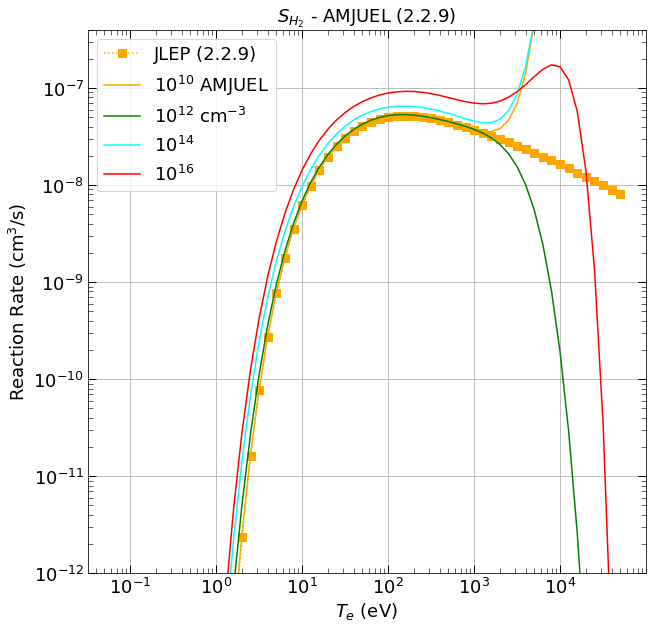

In [8]:
plt.figure(figsize=(10,10))
plt.plot(ehr19Te,aladdin_229,'-s',markersize=8,label='JLEP (2.2.9)',ls=':',color='orange')
plt.plot(ehr19Te,data_229[0,:],label='$10^{10}$ AMJUEL',color='orange')
plt.plot(ehr19Te,data_229[4,:],label='$10^{12}$ cm$^{-3}$',color='green')
plt.plot(ehr19Te,data_229[8,:],label='$10^{14}$',color='cyan')
plt.plot(ehr19Te,data_229[12,:],label='$10^{16}$',color='red')
plt.xlabel('$T_{e}$ (eV)',fontsize=18)
plt.ylabel('Reaction Rate (cm$^{3}$/s)',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
#plt.gca().set_xlim((1.,1.e3))
plt.gca().set_ylim((1.e-12,4.e-7))
plt.gca().grid(axis='both',which='major')
plt.title('$S_{H_{2}}$ - AMJUEL (2.2.9)',fontsize=18)
plt.legend(loc='upper left',fontsize=18)

The behavior of the AMJUEL fit at the lowest $T_{e}$ and highest $n_{e}$ is also problematic.  Note first that the lower $T_{e}$ curves cross over the higher ones. Moreover, the variations with $n_{e}$ here is much stronger than at higher $T_{e}$:

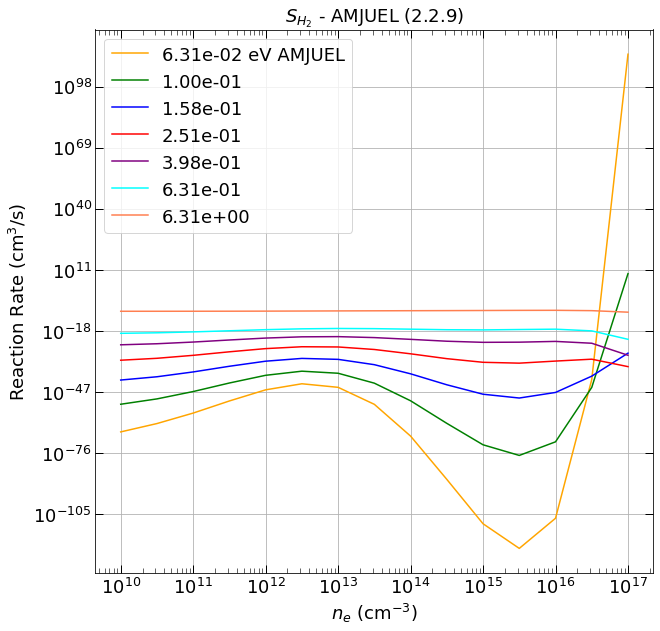

In [9]:
plt.figure(figsize=(10,10))
plt.plot(ehr19ne,data_229[:,0],label='{:.2e}'.format(ehr19Te[0])+' eV AMJUEL',color='orange')
plt.plot(ehr19ne,data_229[:,2],label='{:.2e}'.format(ehr19Te[2]),color='green')
plt.plot(ehr19ne,data_229[:,4],label='{:.2e}'.format(ehr19Te[4]),color='blue')
plt.plot(ehr19ne,data_229[:,6],label='{:.2e}'.format(ehr19Te[6]),color='red')
plt.plot(ehr19ne,data_229[:,8],label='{:.2e}'.format(ehr19Te[8]),color='purple')
plt.plot(ehr19ne,data_229[:,10],label='{:.2e}'.format(ehr19Te[10]),color='cyan')
plt.plot(ehr19ne,data_229[:,20],label='{:.2e}'.format(ehr19Te[20]),color='coral')
plt.xlabel('$n_{e}$ (cm$^{-3}$)',fontsize=18)
plt.ylabel('Reaction Rate (cm$^{3}$/s)',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().grid(axis='both',which='major')
plt.gca().set_xscale('log')
plt.gca().set_yscale('log')
plt.title('$S_{H_{2}}$ - AMJUEL (2.2.9)',fontsize=18)
plt.legend(fontsize=18)

So, in addition to the rescaling above $10^{3}$ eV, we opt to eliminate the $n_{e}$ dependence for the first six ($0 \rightarrow 5$) $T_{e}$ values.

Do the rescaling:

In [10]:
Te_match = np.argwhere(ehr19Te >= 1.e3)[0]
S_H2_rev = np.zeros_like(data_229)
for jn in range(num_ne):
    scale_factor = data_229[jn,Te_match] / aladdin_229[Te_match] 
    for jt in range(num_Te):
        if (jt < Te_match):
            if (jt > 5):
                S_H2_rev[jn,jt] = data_229[jn,jt]
            else:
                S_H2_rev[jn,jt] = data_229[0,jt]
        else:
            S_H2_rev[jn,jt] = scale_factor * aladdin_229[jt]

Reprise the above plots, this time including the previous DEGAS 2 reaction rate:

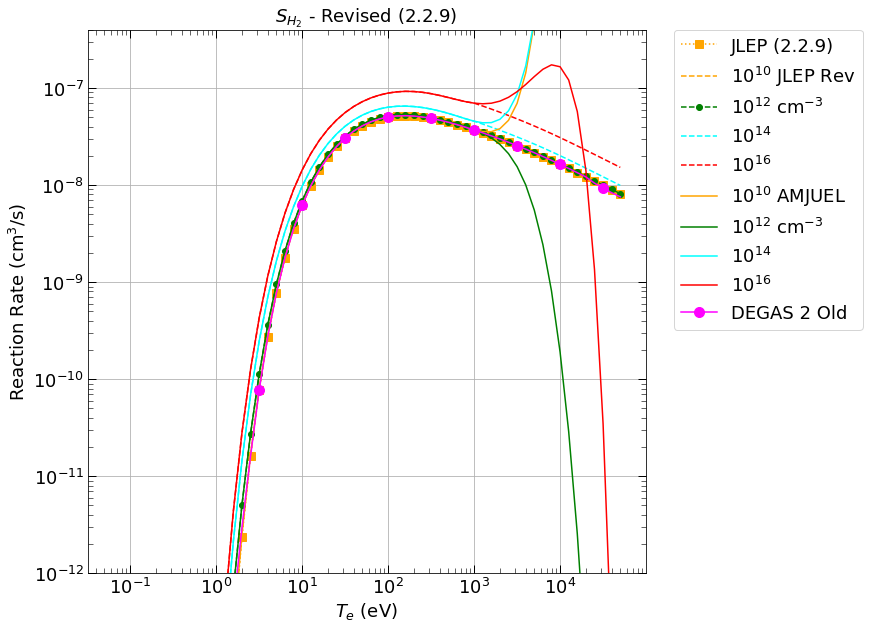

In [11]:
plt.figure(figsize=(10,10))
plt.plot(ehr19Te,aladdin_229,'-s',markersize=8,label='JLEP (2.2.9)',ls=':',color='orange')
plt.plot(ehr19Te,S_H2_rev[0,:],ls='--',
         label='$10^{10}$ JLEP Rev',color='orange')
plt.plot(ehr19Te,S_H2_rev[4,:],'-o',ls='--',
         label='$10^{12}$ cm$^{-3}$',color='green')
plt.plot(ehr19Te,S_H2_rev[8,:],ls='--',
         label='$10^{14}$',color='cyan')
plt.plot(ehr19Te,S_H2_rev[12,:],ls='--',
         label='$10^{16}$',color='red')
plt.plot(ehr19Te,data_229[0,:],label='$10^{10}$ AMJUEL',color='orange')
plt.plot(ehr19Te,data_229[4,:],label='$10^{12}$ cm$^{-3}$',color='green')
plt.plot(ehr19Te,data_229[8,:],label='$10^{14}$',color='cyan')
plt.plot(ehr19Te,data_229[12,:],label='$10^{16}$',color='red')
plt.plot(old_rate[0],old_rate[1],'-o',markersize=10,markevery=5,
         label='DEGAS 2 Old',color='magenta')
plt.xlabel('$T_{e}$ (eV)',fontsize=18)
plt.ylabel('Reaction Rate (cm$^{3}$/s)',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
#plt.gca().set_xlim((1.,1.e3))
plt.gca().set_ylim((1.e-12,4.e-7))
plt.gca().grid(axis='both',which='major')
plt.title('$S_{H_{2}}$ - Revised (2.2.9)',fontsize=18)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left',borderaxespad=0,fontsize=18)

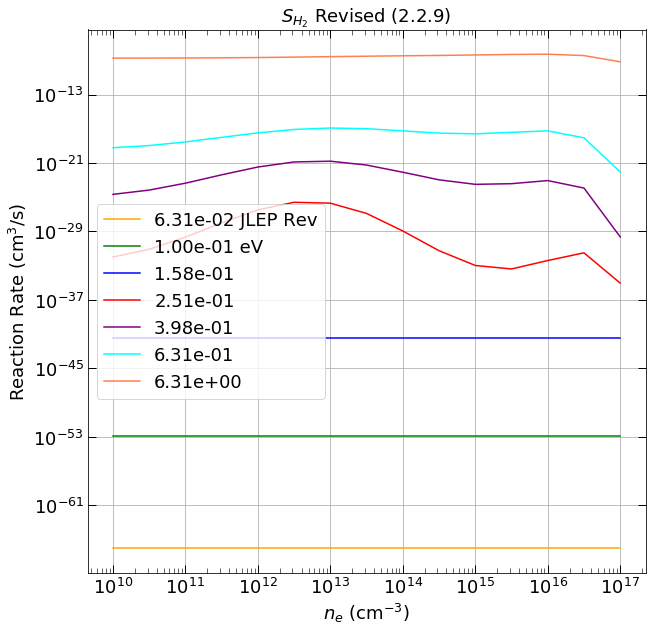

In [12]:
plt.figure(figsize=(10,10))
plt.plot(ehr19ne,S_H2_rev[:,0],label='{:.2e}'.format(ehr19Te[0])+' JLEP Rev',color='orange')
plt.plot(ehr19ne,S_H2_rev[:,2],label='{:.2e}'.format(ehr19Te[2])+' eV',color='green')
plt.plot(ehr19ne,S_H2_rev[:,4],label='{:.2e}'.format(ehr19Te[4]),color='blue')
plt.plot(ehr19ne,S_H2_rev[:,6],label='{:.2e}'.format(ehr19Te[6]),color='red')
plt.plot(ehr19ne,S_H2_rev[:,8],label='{:.2e}'.format(ehr19Te[8]),color='purple')
plt.plot(ehr19ne,S_H2_rev[:,10],label='{:.2e}'.format(ehr19Te[10]),color='cyan')
plt.plot(ehr19ne,S_H2_rev[:,20],label='{:.2e}'.format(ehr19Te[20]),color='coral')
plt.xlabel('$n_{e}$ (cm$^{-3}$)',fontsize=18)
plt.ylabel('Reaction Rate (cm$^{3}$/s)',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().grid(axis='both',which='major')
plt.gca().set_xscale('log')
plt.gca().set_yscale('log')
plt.title('$S_{H_{2}}$ Revised (2.2.9)',fontsize=18)
plt.legend(fontsize=18)

For the energetics, we use the same approach as the original model, which is a constant electron energy loss per ionization, $E_{loss} = 15.4$ eV.  This is the same as in Eirene.

In [13]:
E_loss = 15.4
E_loss_rate = E_loss * S_H2_rev

Compare this loss rate with the one used previously by DEGAS 2:

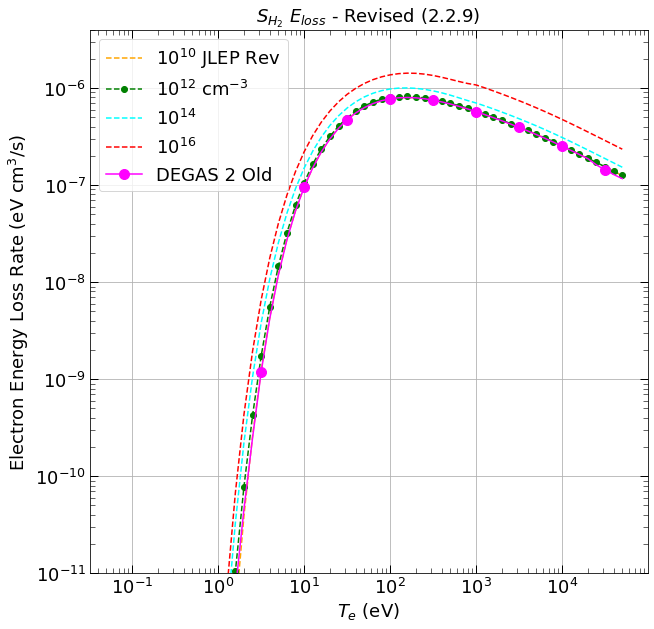

In [14]:
plt.figure(figsize=(10,10))
plt.plot(ehr19Te,E_loss_rate[0,:],ls='--',
         label='$10^{10}$ JLEP Rev',color='orange')
plt.plot(ehr19Te,E_loss_rate[4,:],'-o',ls='--',
         label='$10^{12}$ cm$^{-3}$',color='green')
plt.plot(ehr19Te,E_loss_rate[8,:],ls='--',
         label='$10^{14}$',color='cyan')
plt.plot(ehr19Te,E_loss_rate[12,:],ls='--',
         label='$10^{16}$',color='red')
plt.plot(old_eloss[0],old_eloss[1],'-o',markersize=10,markevery=5,
         label='DEGAS 2 Old',color='magenta')
plt.xlabel('$T_{e}$ (eV)',fontsize=18)
plt.ylabel('Electron Energy Loss Rate (eV cm$^{3}$/s)',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
#plt.gca().set_xlim((1.,1.e3))
plt.gca().set_ylim((1.e-11,4.e-6))
plt.gca().grid(axis='both',which='major')
plt.title('$S_{H_{2}}$ $E_{loss}$ - Revised (2.2.9)',fontsize=18)
plt.legend(fontsize=18)

The designation "JCR" in the name of this and the other associated molecular dissociation reaction files stands for "Janev Collisional Radiative" since the original approach was to use the Janev rates for the dissociative excitation product distribution in *collrad*.

Writing the data to the netCDF file consists of two steps.  The first involves defining the independent and dependent variables and then setting up the data table that holds all of the actual rate data.

The variables being written to this file are:  

0. Reaction rate(temperature,density)
1. Background energy loss rate (temperature,density)

As above, there are num_ne density values and num_Te temperature values. Note that we change from using (density,temperature)  in these notebooks to (temperature,density) in the netCDF files.  The latter is to be consistent with the convention in the H CR files, such as hionize5.nc. 

This initialization call sets the name of the reaction and the netCDF file, and specifies the number of dependent variables.

In [15]:
h2ion_jcr = xs.xs_data('h2ion_jcr',2)

Now, loop through the variables, providing the name, evaluation name (not really used), dimensions, units, multiplier, independent variable minimum and maximum, and the spacing method used for interpolation.

In [16]:
h2ion_jcr.set_var(0,['reaction_rate','temperature','density'],'table',
              [num_Te,num_ne],['cm^3/s','eV','cm^-3'],
              [1.e-6,xs.electron_charge,1.e6],
              [ehr19Te[0],ehr19ne[0]],
              [ehr19Te[-1],ehr19ne[-1]],
              ['log']*3)

In [17]:
h2ion_jcr.set_var(1,['background_energy_loss_rate','temperature','density'],'table',
              [num_Te,num_ne],['eV*cm^3/s','eV','cm^-3'],
              [1.e-6*xs.electron_charge,xs.electron_charge,1.e6],
              [ehr19Te[0],ehr19ne[0]],
              [ehr19Te[-1],ehr19ne[-1]],
              ['log']*3)

Fill in the data table.

In [18]:
h2ion_jcr.set_data(0,S_H2_rev.T)
h2ion_jcr.set_data(1,E_loss_rate.T)

Now open the netCDF file, write in the data using the h2ion xs_data data structures, and close the file.

In [19]:
work_dir = './'
h2ion_jcr_nc = xs.xs_netCDF.write_ncfile(h2ion_jcr,work_dir,
                       'Reference atomic physics data for a reaction in degas 2',
                       'V. 1.0, effective H2 ionization with CR effects')
h2ion_jcr_nc.close()

Note that the xs_data structures can be accessed within this notebook:

In [20]:
print(h2ion_jcr.tab_index)

[[60 15  1]
 [60 15  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]
 [ 1  1  1]]


In [21]:
print(S_H2_rev.shape)

(15, 60)
